In [1]:
# All Newman-alpha-scheme machinery (centering, Jacobians, LCF/spectral-gap
# computation, sync/async updates, MLE fitting, SBM data generation) now
# lives in utils.py -- see that file for full documentation of each function.
# utils.py must be in the same directory as this notebook (or on sys.path).
from utils import *

import matplotlib.pyplot as plt
from matplotlib import rc
from matplotlib.colors import to_rgb

## Homogeneous

Converged in 18 iterations (l2 error = 3.594e-16).


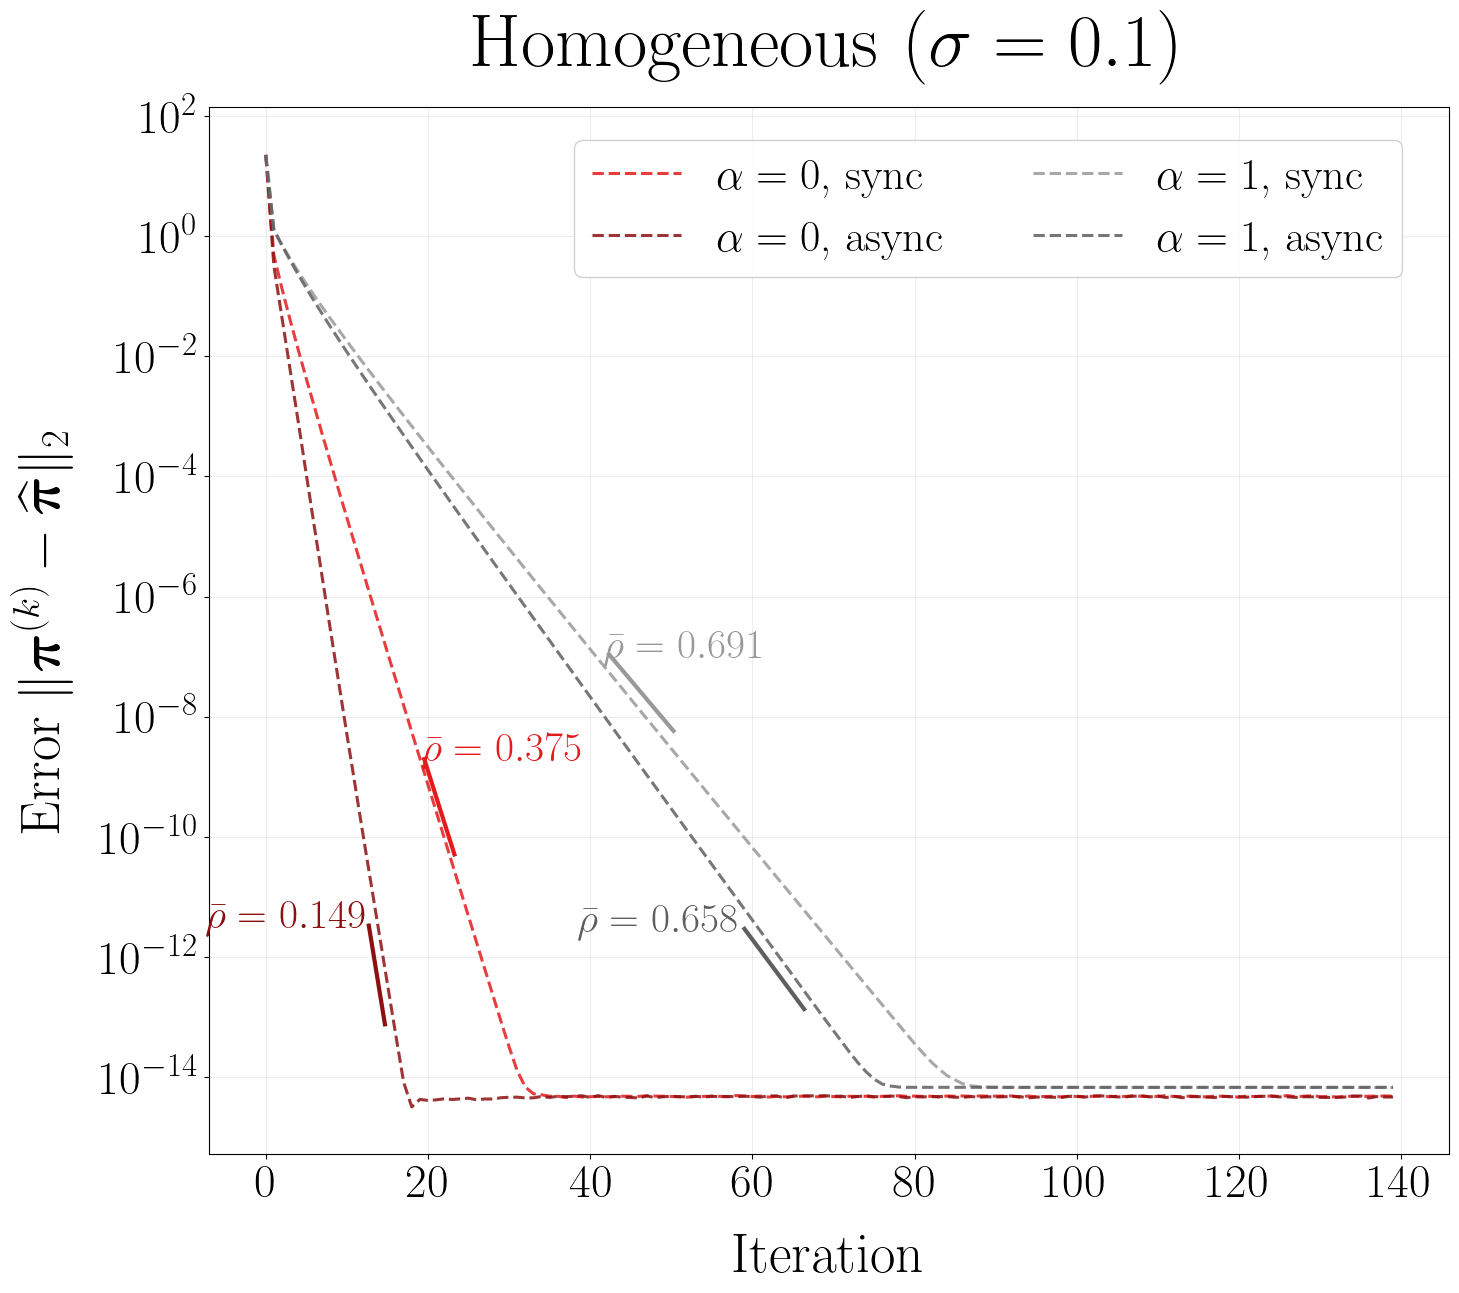

Converged in 19 iterations (l2 error = 2.635e-16).


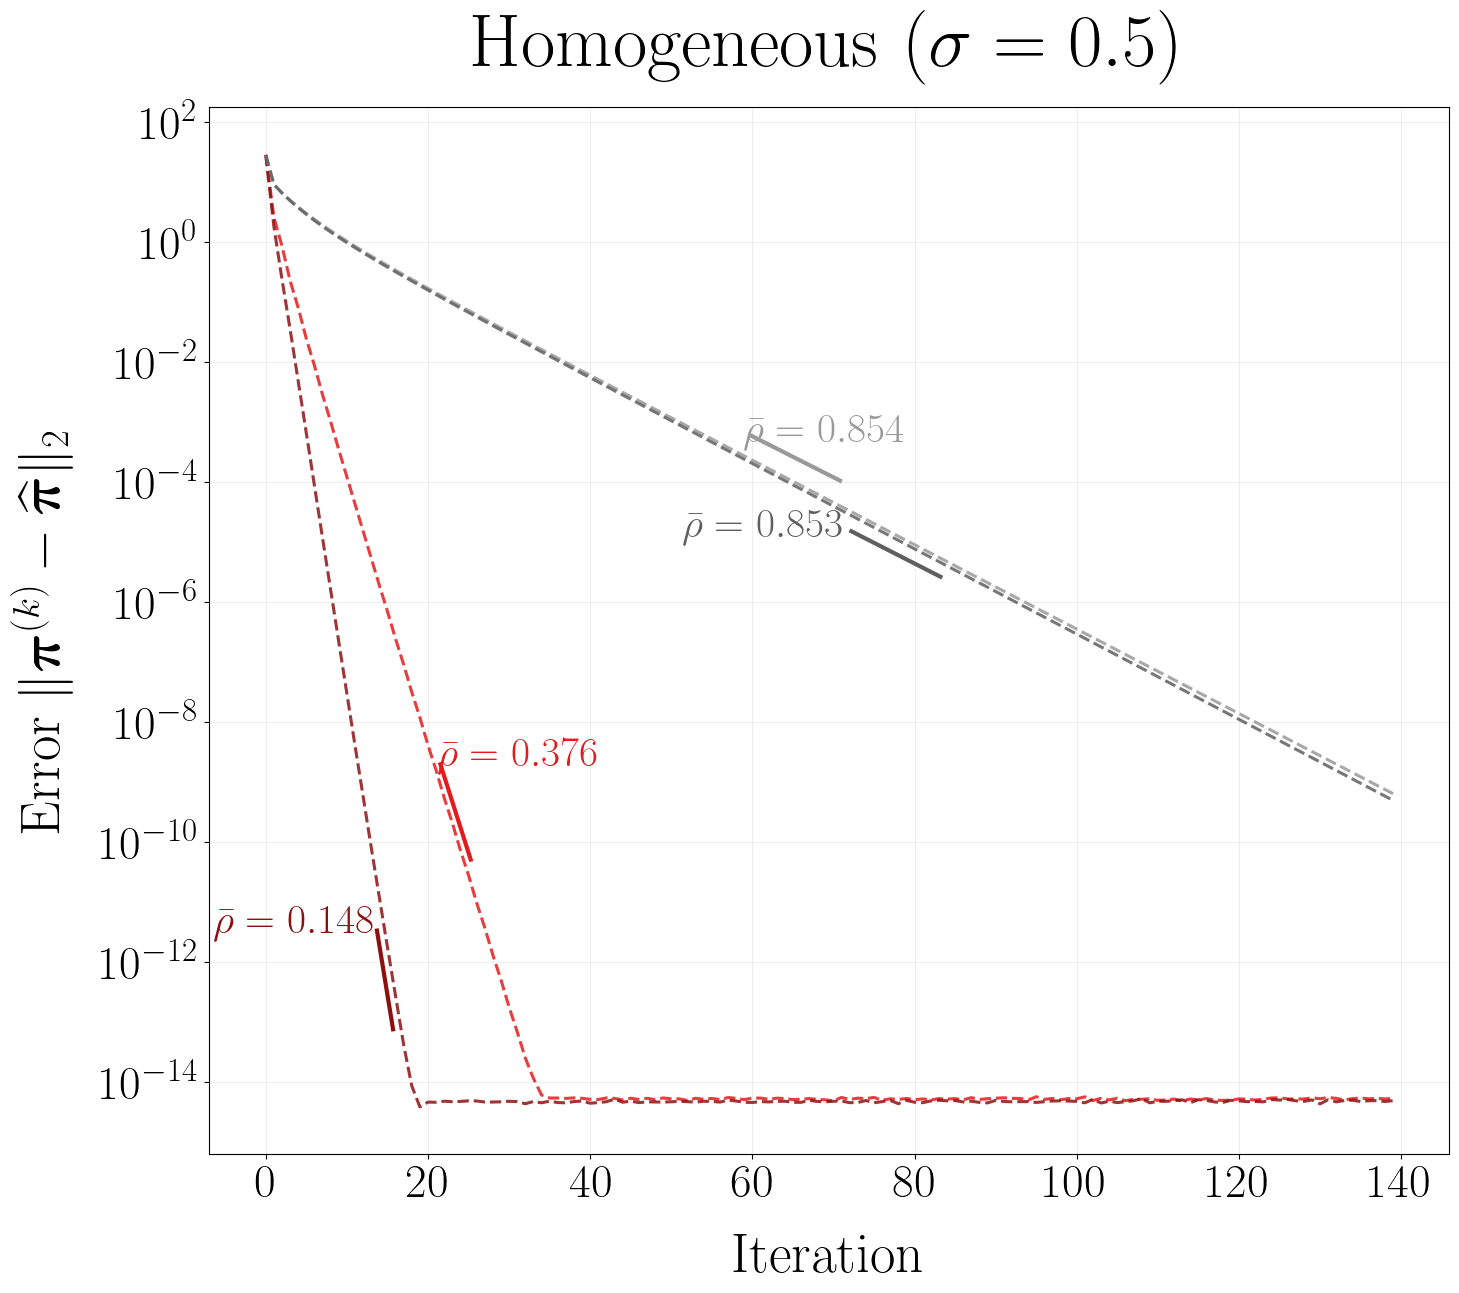

In [2]:
graph = 'balanced'
n     = 500
size  = (16, 13.6)

if graph == 'balanced':
    p, q = 0.05, 0.05
elif graph == 'cluster':
    p, q = 0.1, 0.01
elif graph == 'bipartite':
    p, q = 0.01, 0.1

alpha_set = [0, 1]
sigma_set  = [0.1, 0.5]

A = sbm_2block(n, p, q, seed=1114)

base_colors = plt.cm.Set1(np.linspace(0, 1, len(alpha_set)))

def shade_color(color, factor):
    r, g, b = to_rgb(color)
    return (min(max(r*factor,0),1), min(max(g*factor,0),1), min(max(b*factor,0),1))

COLORS = {
    (0, 'full'): base_colors[0],
    (0, 'none'): shade_color(base_colors[0], 0.62),
    (1, 'full'): base_colors[1],
    (1, 'none'): shade_color(base_colors[1], 0.62),
}
MARKERS = {
    (0, 'full'): 'o',
    (0, 'none'): 's',
    (1, 'full'): '^',
    (1, 'none'): 'D',
}
LABELS = {
    (0, 'full'): r'$\alpha=0$, sync',
    (0, 'none'): r'$\alpha=0$, async',
    (1, 'full'): r'$\alpha=1$, sync',
    (1, 'none'): r'$\alpha=1$, async',
}

OBS_KW = dict(linewidth=2.2, alpha=0.85, linestyle='--')
SEG_PX = 100

# ── Per-sigma configuration ───────────────────────────────────────────────────
ANCHOR_LEV = {
    0.1: {
        (0, 'full'): 1e-10,
        (0, 'none'): 1e-12,
        (1, 'full'): 1e-8,
        (1, 'none'): 1e-12,
    },
    0.5: {
        (0, 'full'): 1e-10,
        (0, 'none'): 1e-12,
        (1, 'full'): 1e-4,
        (1, 'none'): 1e-5,
    },
}

SEG_PLACEMENT = {
    0.1: {
        (0, 'none'): dict(y_shift_log=-0.3, x_shift=-0.3, lbl_side='left'),
        (0, 'full'): dict(y_shift_log= 0.5, x_shift= 0.4, lbl_side='right'),
        (1, 'none'): dict(y_shift_log=-0.2, x_shift=-0.3, lbl_side='left'),
        (1, 'full'): dict(y_shift_log= 0.4, x_shift= 0.3, lbl_side='right'),
    },
    0.5: {
        (0, 'none'): dict(y_shift_log=-0.3, x_shift=-0.3, lbl_side='left'),
        (0, 'full'): dict(y_shift_log= 0.5, x_shift= 0.4, lbl_side='right'),
        (1, 'none'): dict(y_shift_log=-0.2, x_shift=-0.3, lbl_side='left'),
        (1, 'full'): dict(y_shift_log= 0.4, x_shift= 0.3, lbl_side='right'),
    },
}


def collect_segment_info(error_arr, t_slope):
    arr = np.array(error_arr)
    if t_slope >= 0:
        return None
    return dict(t_slope=t_slope, errors=arr)


def draw_fixed_length_segments(ax, seg_infos, colors, keys, sigma,
                                half_px=SEG_PX // 2, fontsize=30):
    trans     = ax.transData
    trans_inv = ax.transData.inverted()

    anchor_lev_map  = ANCHOR_LEV[sigma]
    placement_map   = SEG_PLACEMENT[sigma]

    for info, color, key in zip(seg_infos, colors, keys):
        if info is None:
            continue

        t_slope    = info['t_slope']
        rho_val    = 10 ** t_slope
        pl         = placement_map[key]
        arr        = np.array(info['errors'])
        anchor_lev = anchor_lev_map[key]

        above = np.where(arr >= anchor_lev)[0]
        if len(above) == 0:
            above = np.where(arr >= 1e-3)[0]
        if len(above) == 0:
            continue

        x_anchor = int(above[-1]) + pl['x_shift']
        x_anchor = min(max(x_anchor, 1), len(arr) - 2)
        y_anchor = anchor_lev * (10 ** pl['y_shift_log'])

        eps  = 0.5
        y_lo = y_anchor * 10 ** (t_slope * (-eps))
        y_hi = y_anchor * 10 ** (t_slope * ( eps))

        p_lo = trans.transform((x_anchor - eps, y_lo))
        p_hi = trans.transform((x_anchor + eps, y_hi))

        direction = p_hi - p_lo
        unit_dir  = direction / np.linalg.norm(direction)

        p_mid      = trans.transform((x_anchor, y_anchor))
        p_start_px = p_mid - half_px * unit_dir
        p_end_px   = p_mid + half_px * unit_dir

        x_s, y_s = trans_inv.transform(p_start_px)
        x_e, y_e = trans_inv.transform(p_end_px)

        ax.semilogy([x_s, x_e], [y_s, y_e],
                    color=color, linestyle='-',
                    linewidth=3, zorder=5, alpha=1.0)

        if pl['lbl_side'] == 'left':
            x_lbl, y_lbl = trans_inv.transform(p_start_px - 8 * unit_dir)
            ha = 'right'
        else:
            x_lbl, y_lbl = trans_inv.transform(p_start_px - 8 * unit_dir)
            ha = 'left'

        ax.text(x_lbl, y_lbl,
                rf'$\bar{{\rho}}={rho_val:.3f}$',
                fontsize = fontsize,
                color    = color,
                ha       = ha,
                va       = 'center')


# ── Main loop ─────────────────────────────────────────────────────────────────
rc('text', usetex=True)
rc('font', family='serif')
rc('text.latex', preamble=r'\usepackage{bm}')   # needed for \bm{} in the y-axis label below

for sigma in sigma_set:
    rng        = np.random.default_rng(365)
    gamma_true = rng.lognormal(0, sigma, n)
    gamma_true = centering(gamma_true)

    np.random.seed(1023)
    W, win_list, loss_list, mle = get_data(A, 100, gamma_true)

    t_slopes = {
        (a, sync): np.log10(1-get_gap(W, gamma_true, alpha=a, sync=sync))
        for a in alpha_set for sync in ['full', 'none']
    }

    N   = 140
    fig, ax = plt.subplots(figsize=size)

    seg_infos  = []
    seg_colors = []
    seg_keys   = []

    for a in alpha_set:
        for sync in ['full', 'none']:
            color  = COLORS[(a, sync)]
            marker = MARKERS[(a, sync)]

            gamma  = np.ones(n) / n
            errors = []
            for _ in range(N):
                errors.append(np.linalg.norm(gamma - mle, ord=2))
                gamma = newman_update(gamma, win_list, loss_list,
                                      alpha=a, sync=sync)

            every = max(1, N // 8)
            ax.semilogy(errors, color=color,
                        label=LABELS[(a, sync)], **OBS_KW)

            seg_infos.append(collect_segment_info(errors, t_slopes[(a, sync)]))
            seg_colors.append(color)
            seg_keys.append((a, sync))

    if graph == 'balanced' and sigma == 0.1:
        ax.legend(fontsize=32, loc='upper right',
                  bbox_to_anchor=(0.98, 0.99),
                  ncol=2, framealpha=0.88)

    ax.set_title(rf"$\mathrm{{Homogeneous}}\ (\sigma = {sigma})$",
                 fontsize=54, color='black', pad=30)
    ax.grid(True, linewidth=0.4, alpha=0.4)
    ax.set_xlabel(r'Iteration', fontsize=40, labelpad=20)
    ax.set_ylabel(r'Error $\|\bm{\pi}^{(k)}-\widehat{\bm{\pi}}\|_2$', fontsize=40, labelpad=20)
    ax.tick_params(axis='both', which='major', labelsize=34)

    fig.canvas.draw()
    draw_fixed_length_segments(ax, seg_infos, seg_colors, seg_keys, sigma=sigma)

    plt.savefig(f'history_{graph}_{int(sigma * 10)}.pdf')
    plt.show()

## Cluster

Converged in 80 iterations (l2 error = 4.661e-16).


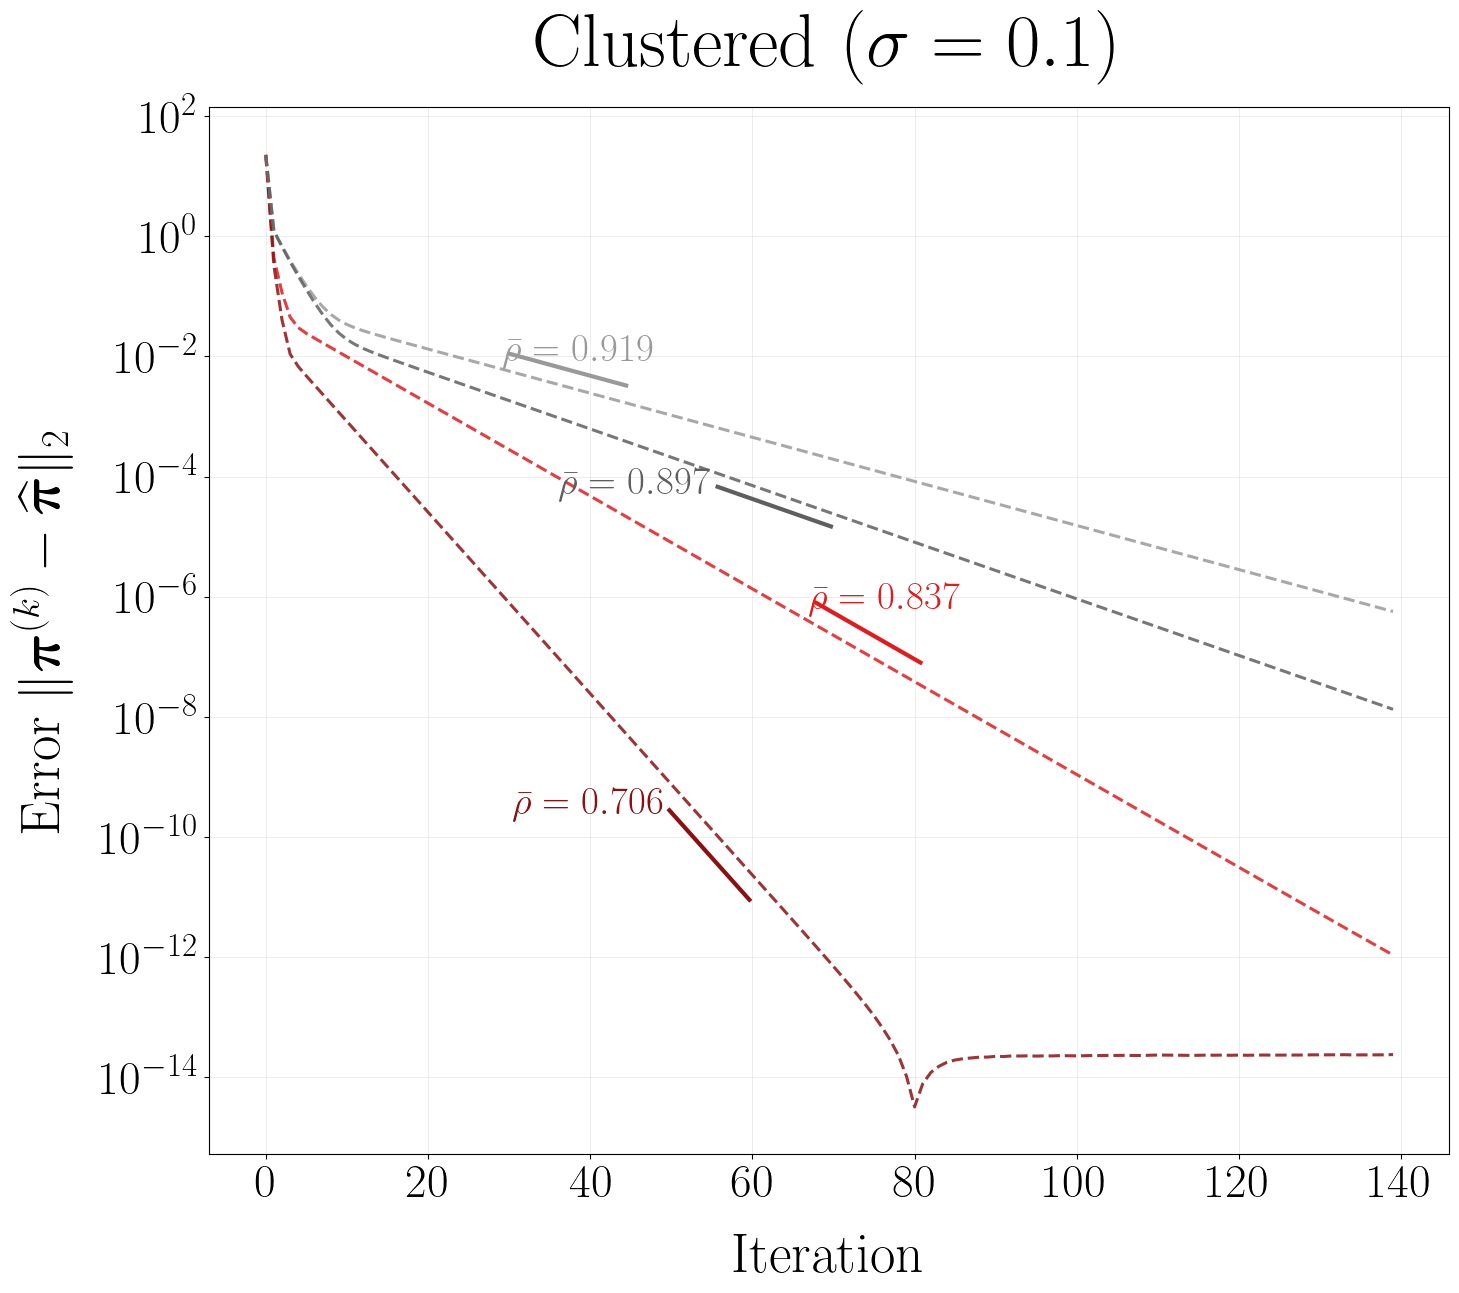

Converged in 85 iterations (l2 error = 3.910e-16).


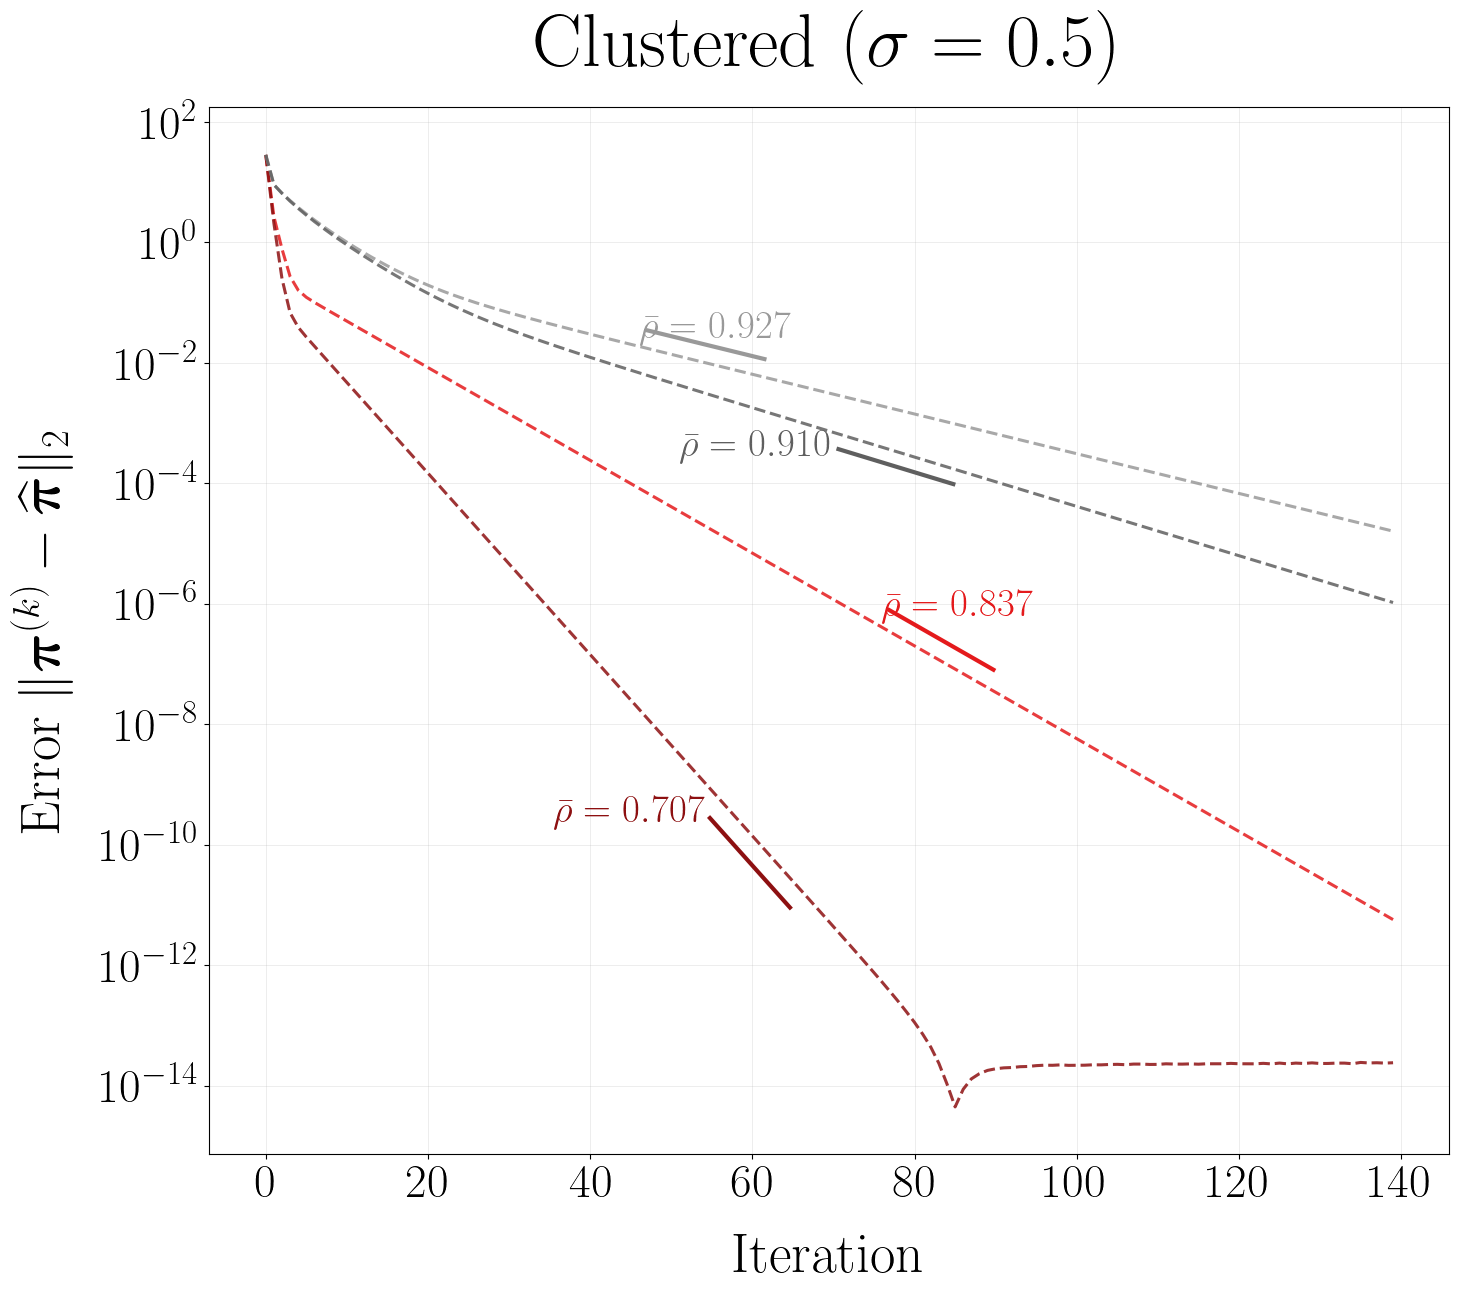

In [3]:
graph = 'cluster'
n     = 500
size  = (16, 13.6)

if graph == 'balanced':
    p, q = 0.05, 0.05
elif graph == 'cluster':
    p, q = 0.1, 0.01
elif graph == 'bipartite':
    p, q = 0.01, 0.1

alpha_set = [0, 1]
sigma_set  = [0.1, 0.5]

A = sbm_2block(n, p, q, seed=2026)

base_colors = plt.cm.Set1(np.linspace(0, 1, len(alpha_set)))

def shade_color(color, factor):
    r, g, b = to_rgb(color)
    return (min(max(r*factor,0),1), min(max(g*factor,0),1), min(max(b*factor,0),1))

COLORS = {
    (0, 'full'): base_colors[0],
    (0, 'none'): shade_color(base_colors[0], 0.62),
    (1, 'full'): base_colors[1],
    (1, 'none'): shade_color(base_colors[1], 0.62),
}
MARKERS = {
    (0, 'full'): 'o',
    (0, 'none'): 's',
    (1, 'full'): '^',
    (1, 'none'): 'D',
}
LABELS = {
    (0, 'full'): r'$\alpha=0$, sync',
    (0, 'none'): r'$\alpha=0$, async',
    (1, 'full'): r'$\alpha=1$, sync',
    (1, 'none'): r'$\alpha=1$, async',
}

OBS_KW = dict(linewidth=2.2, alpha=0.85, linestyle='--')
SEG_PX = 120

ANCHOR_LEV = {
    0.1: {
        (0, 'full'): 1e-7,
        (0, 'none'): 1e-10,
        (1, 'full'): 3e-3,
        (1, 'none'): 5e-5,
    },
    0.5: {
        (0, 'full'): 1e-7,
        (0, 'none'): 1e-10,
        (1, 'full'): 1e-2,
        (1, 'none'): 3e-4,
    },
}

SEG_PLACEMENT = {
    0.1: {
        (0, 'none'): dict(y_shift_log=-0.3, x_shift=-0.3, lbl_side='left'),
        (0, 'full'): dict(y_shift_log= 0.4, x_shift= 0.3, lbl_side='right'),
        (1, 'none'): dict(y_shift_log=-0.2, x_shift=-0.3, lbl_side='left'),
        (1, 'full'): dict(y_shift_log= 0.3, x_shift= 0.3, lbl_side='right'),
    },
    0.5: {
        (0, 'none'): dict(y_shift_log=-0.3, x_shift=-0.3, lbl_side='left'),
        (0, 'full'): dict(y_shift_log= 0.4, x_shift= 0.3, lbl_side='right'),
        (1, 'none'): dict(y_shift_log=-0.2, x_shift=-0.3, lbl_side='left'),
        (1, 'full'): dict(y_shift_log= 0.3, x_shift= 0.3, lbl_side='right'),
    },
}


def collect_segment_info(error_arr, t_slope):
    arr = np.array(error_arr)
    if t_slope >= 0:
        return None
    return dict(t_slope=t_slope, errors=arr)


def draw_fixed_length_segments(ax, seg_infos, colors, keys, sigma,
                                half_px=SEG_PX // 2, fontsize=28):
    trans     = ax.transData
    trans_inv = ax.transData.inverted()

    anchor_lev_map = ANCHOR_LEV[sigma]
    placement_map  = SEG_PLACEMENT[sigma]

    for info, color, key in zip(seg_infos, colors, keys):
        if info is None:
            continue

        t_slope    = info['t_slope']
        rho_val    = 10 ** t_slope
        pl         = placement_map[key]
        arr        = np.array(info['errors'])
        anchor_lev = anchor_lev_map[key]

        above = np.where(arr >= anchor_lev)[0]
        if len(above) == 0:
            above = np.where(arr >= 1e-3)[0]
        if len(above) == 0:
            continue

        x_anchor = int(above[-1]) + pl['x_shift']
        x_anchor = min(max(x_anchor, 1), len(arr) - 2)
        y_anchor = anchor_lev * (10 ** pl['y_shift_log'])

        eps  = 0.5
        y_lo = y_anchor * 10 ** (t_slope * (-eps))
        y_hi = y_anchor * 10 ** (t_slope * ( eps))

        p_lo = trans.transform((x_anchor - eps, y_lo))
        p_hi = trans.transform((x_anchor + eps, y_hi))

        direction = p_hi - p_lo
        unit_dir  = direction / np.linalg.norm(direction)

        p_mid      = trans.transform((x_anchor, y_anchor))
        p_start_px = p_mid - half_px * unit_dir
        p_end_px   = p_mid + half_px * unit_dir

        x_s, y_s = trans_inv.transform(p_start_px)
        x_e, y_e = trans_inv.transform(p_end_px)

        ax.semilogy([x_s, x_e], [y_s, y_e],
                    color=color, linestyle='-',
                    linewidth=3, zorder=5, alpha=1.0)

        if pl['lbl_side'] == 'left':
            x_lbl, y_lbl = trans_inv.transform(p_start_px - 8 * unit_dir)
            ha = 'right'
        else:
            x_lbl, y_lbl = trans_inv.transform(p_start_px - 8 * unit_dir)
            ha = 'left'

        ax.text(x_lbl, y_lbl,
                rf'$\bar{{\rho}}={rho_val:.3f}$',
                fontsize = fontsize,
                color    = color,
                ha       = ha,
                va       = 'center')


# ── Main loop ─────────────────────────────────────────────────────────────────
rc('text', usetex=True)
rc('font', family='serif')
rc('text.latex', preamble=r'\usepackage{bm}')   # needed for \bm{} in the y-axis label below

for sigma in sigma_set:
    rng        = np.random.default_rng(365)
    gamma_true = rng.lognormal(0, sigma, n)
    gamma_true = centering(gamma_true)

    np.random.seed(1023)
    W, win_list, loss_list, mle = get_data(A, 100, gamma_true)

    t_slopes = {
        (a, sync): np.log10(1-get_gap(W, gamma_true, alpha=a, sync=sync))
        for a in alpha_set for sync in ['full', 'none']
    }

    N   = 140
    fig, ax = plt.subplots(figsize=size)

    seg_infos  = []
    seg_colors = []
    seg_keys   = []

    for a in alpha_set:
        for sync in ['full', 'none']:
            color  = COLORS[(a, sync)]
            marker = MARKERS[(a, sync)]

            gamma  = np.ones(n) / n
            errors = []
            for _ in range(N):
                errors.append(np.linalg.norm(gamma - mle, ord=2))
                gamma = newman_update(gamma, win_list, loss_list,
                                      alpha=a, sync=sync)

            every = max(1, N // 8)
            ax.semilogy(errors, color=color,
                        label=LABELS[(a, sync)], **OBS_KW)

            seg_infos.append(collect_segment_info(errors, t_slopes[(a, sync)]))
            seg_colors.append(color)
            seg_keys.append((a, sync))

    if graph == 'balanced' and sigma == 0.1:
        ax.legend(fontsize=32, loc='upper right',
                  bbox_to_anchor=(0.98, 0.99),
                  ncol=2, framealpha=0.88)

    ax.set_title(rf"$\mathrm{{Clustered}}\ (\sigma = {sigma})$",
                 fontsize=54, color='black', pad=30)
    ax.grid(True, linewidth=0.4, alpha=0.4)
    ax.set_xlabel(r'Iteration', fontsize=40, labelpad=20)
    ax.set_ylabel(r'Error $\|\bm{\pi}^{(k)}-\widehat{\bm{\pi}}\|_2$', fontsize=40, labelpad=20)
    ax.tick_params(axis='both', which='major', labelsize=34)

    fig.canvas.draw()
    draw_fixed_length_segments(ax, seg_infos, seg_colors, seg_keys, sigma=sigma)

    plt.savefig(f'history_{graph}_{int(sigma * 10)}.pdf')
    plt.show()

## Near-bipartite

Converged in 17 iterations (l2 error = 1.952e-16).


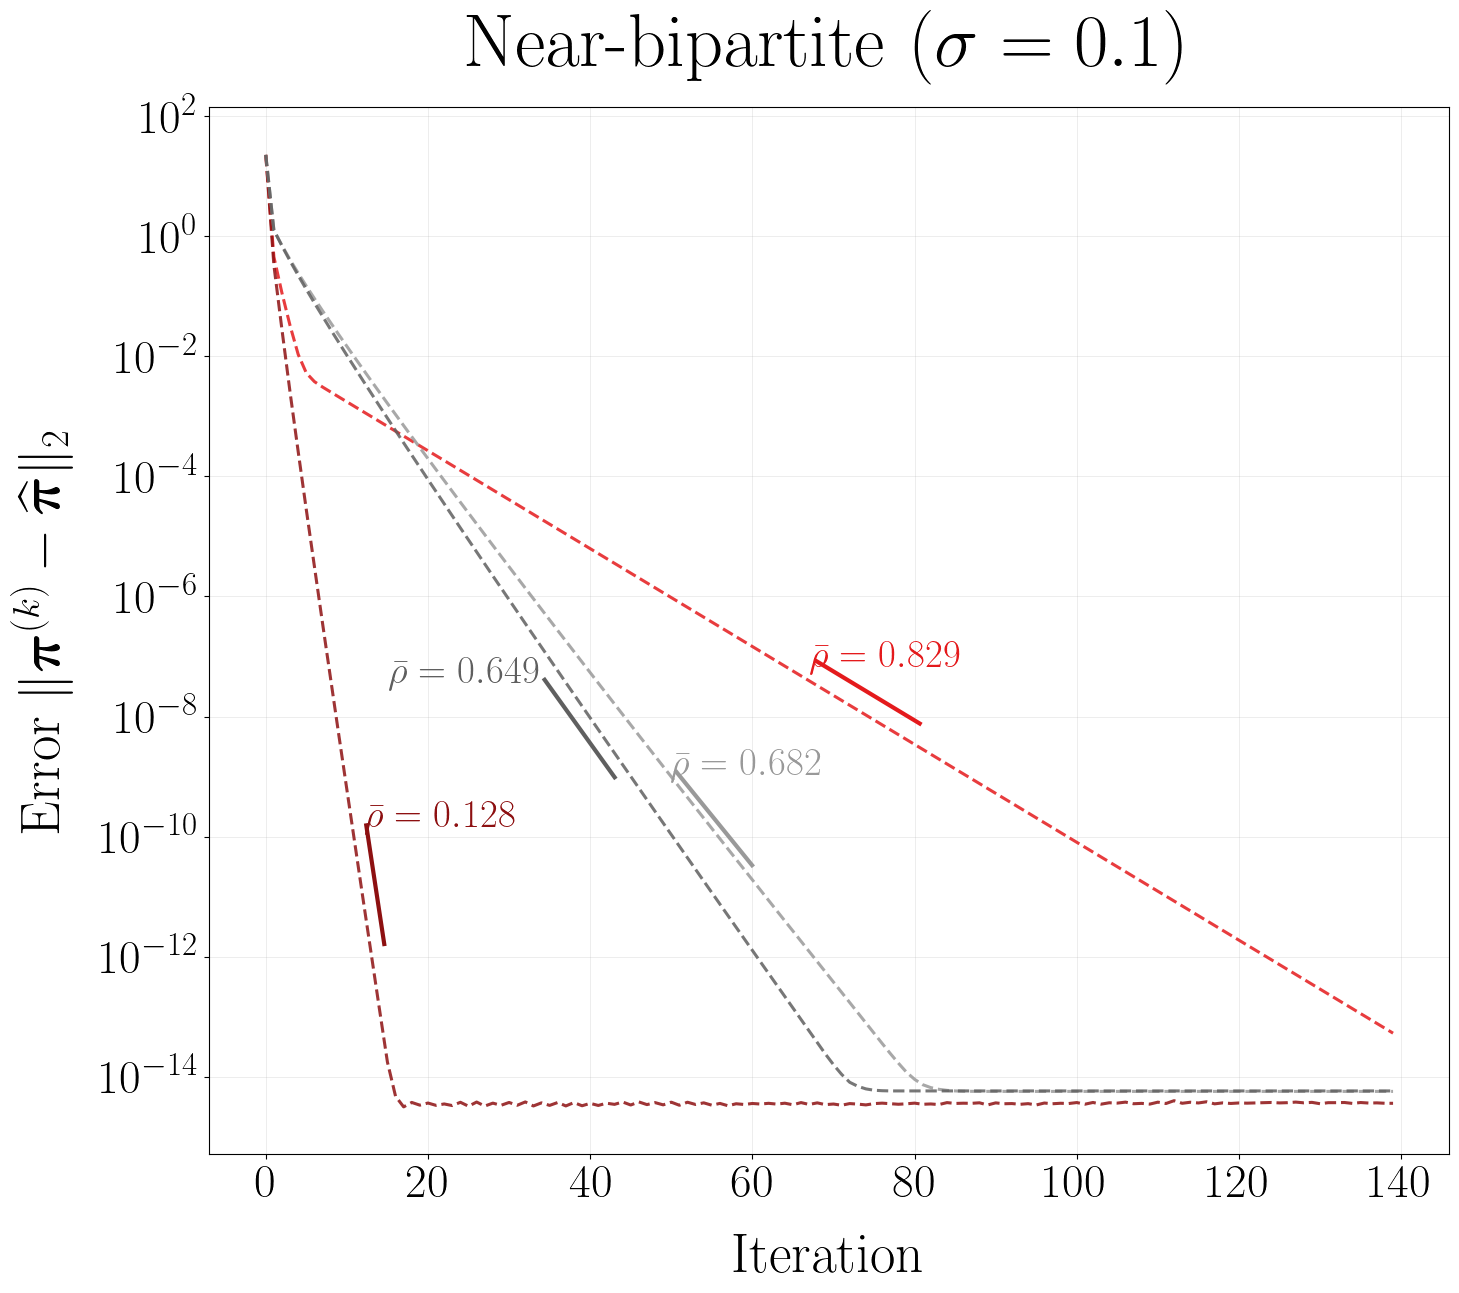

Converged in 17 iterations (l2 error = 4.501e-16).


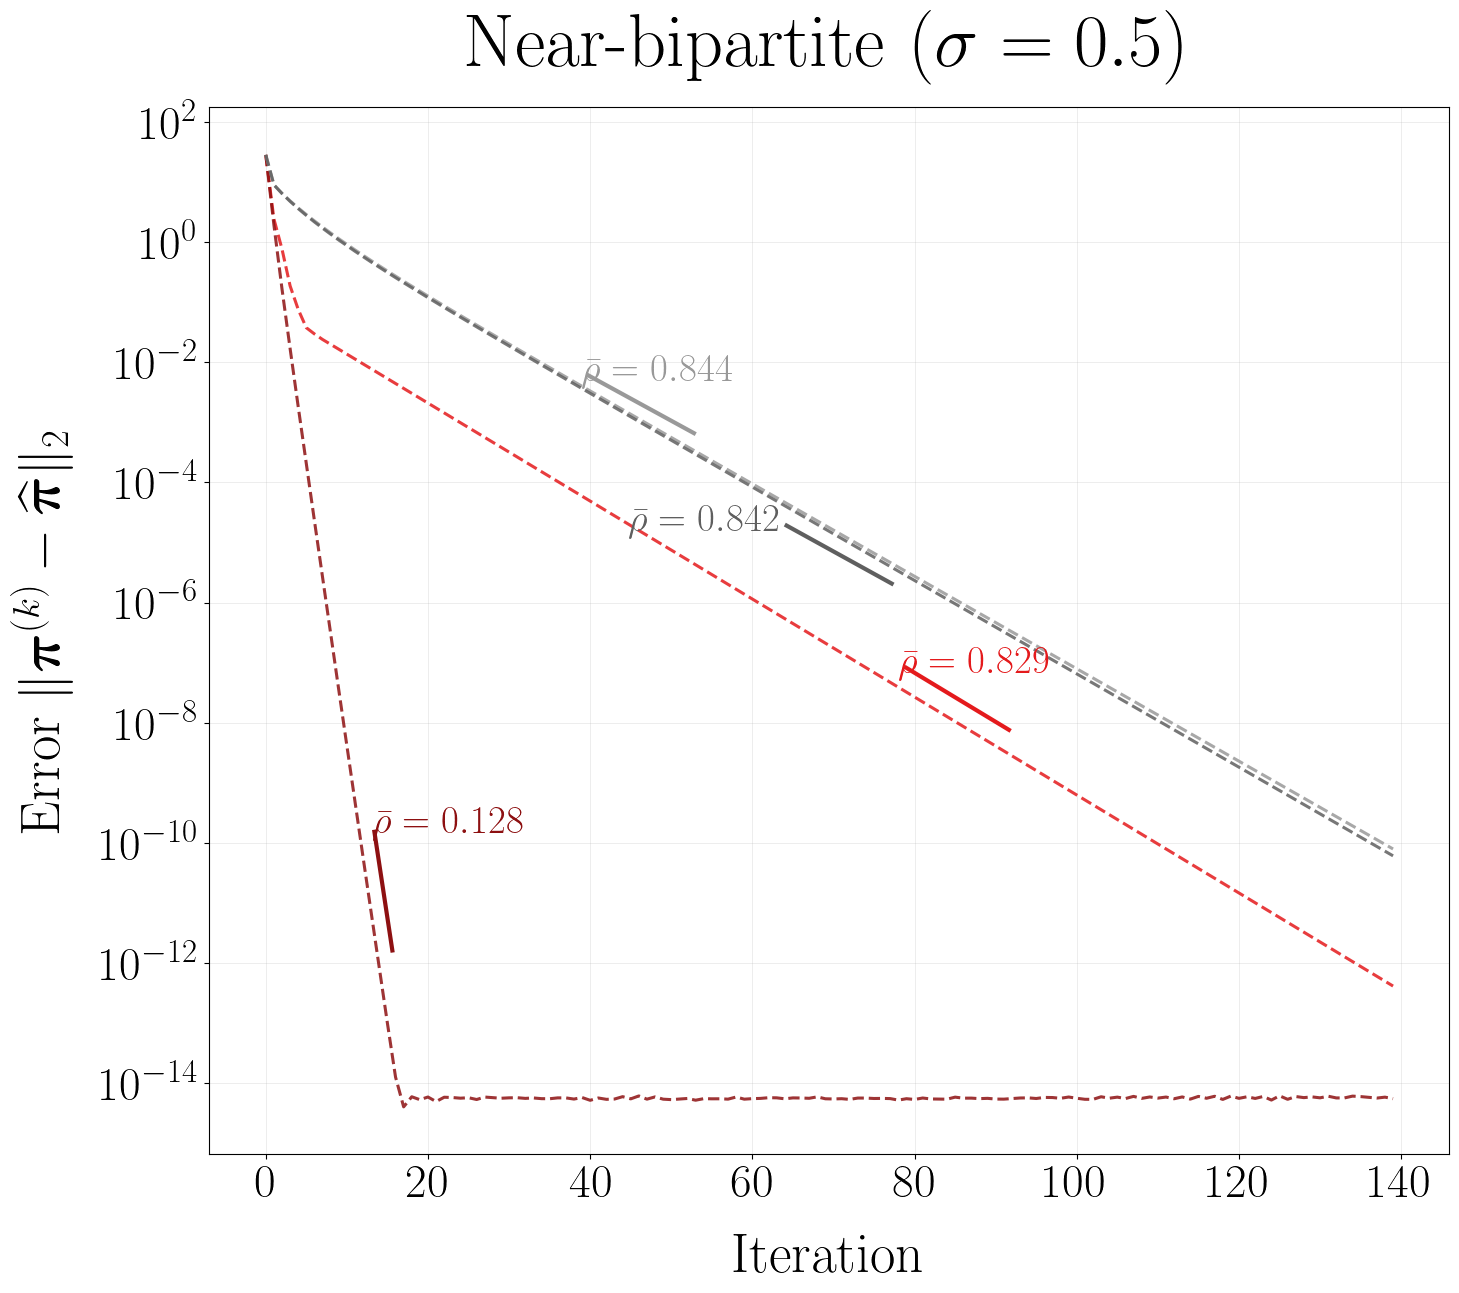

In [4]:
graph = 'bipartite'
n     = 500
size  = (16, 13.6)

if graph == 'balanced':
    p, q = 0.05, 0.05
elif graph == 'cluster':
    p, q = 0.1, 0.01
elif graph == 'bipartite':
    p, q = 0.01, 0.1

alpha_set = [0, 1]
sigma_set  = [0.1, 0.5]

A = sbm_2block(n, p, q, seed=2026)

base_colors = plt.cm.Set1(np.linspace(0, 1, len(alpha_set)))

def shade_color(color, factor):
    r, g, b = to_rgb(color)
    return (min(max(r*factor,0),1), min(max(g*factor,0),1), min(max(b*factor,0),1))

COLORS = {
    (0, 'full'): base_colors[0],
    (0, 'none'): shade_color(base_colors[0], 0.62),
    (1, 'full'): base_colors[1],
    (1, 'none'): shade_color(base_colors[1], 0.62),
}
MARKERS = {
    (0, 'full'): 'o',
    (0, 'none'): 's',
    (1, 'full'): '^',
    (1, 'none'): 'D',
}
LABELS = {
    (0, 'full'): r'$\alpha=0$, sync',
    (0, 'none'): r'$\alpha=0$, async',
    (1, 'full'): r'$\alpha=1$, sync',
    (1, 'none'): r'$\alpha=1$, async',
}

OBS_KW = dict(linewidth=2.2, alpha=0.85, linestyle='--')
SEG_PX = 120

ANCHOR_LEV = {
    0.1: {
        (0, 'full'): 1e-8,
        (0, 'none'): 5e-11,
        (1, 'full'): 1e-10,
        (1, 'none'): 1e-8,
    },
    0.5: {
        (0, 'full'): 1e-8,
        (0, 'none'): 5e-11,
        (1, 'full'): 1e-3,
        (1, 'none'): 1e-5,
    },
}

SEG_PLACEMENT = {
    0.1: {
        (0, 'none'): dict(y_shift_log=-0.5, x_shift= 2.5, lbl_side='right'),
        (0, 'full'): dict(y_shift_log= 0.4, x_shift= 0.3, lbl_side='right'),
        (1, 'none'): dict(y_shift_log=-0.2, x_shift=-0.3, lbl_side='left'),
        (1, 'full'): dict(y_shift_log= 0.3, x_shift= 0.3, lbl_side='right'),
    },
    0.5: {
        (0, 'none'): dict(y_shift_log=-0.5, x_shift= 2.5, lbl_side='right'),
        (0, 'full'): dict(y_shift_log= 0.4, x_shift= 0.3, lbl_side='right'),
        (1, 'none'): dict(y_shift_log=-0.2, x_shift=-0.3, lbl_side='left'),
        (1, 'full'): dict(y_shift_log= 0.3, x_shift= 0.3, lbl_side='right'),
    },
}


def collect_segment_info(error_arr, t_slope):
    arr = np.array(error_arr)
    if t_slope >= 0:
        return None
    return dict(t_slope=t_slope, errors=arr)


def draw_fixed_length_segments(ax, seg_infos, colors, keys, sigma,
                                half_px=SEG_PX // 2, fontsize=28):
    trans     = ax.transData
    trans_inv = ax.transData.inverted()

    anchor_lev_map = ANCHOR_LEV[sigma]
    placement_map  = SEG_PLACEMENT[sigma]

    for info, color, key in zip(seg_infos, colors, keys):
        if info is None:
            continue

        t_slope    = info['t_slope']
        rho_val    = 10 ** t_slope
        pl         = placement_map[key]
        arr        = np.array(info['errors'])
        anchor_lev = anchor_lev_map[key]

        above = np.where(arr >= anchor_lev)[0]
        if len(above) == 0:
            above = np.where(arr >= 1e-3)[0]
        if len(above) == 0:
            continue

        x_anchor = int(above[-1]) + pl['x_shift']
        x_anchor = min(max(x_anchor, 1), len(arr) - 2)
        y_anchor = anchor_lev * (10 ** pl['y_shift_log'])

        eps  = 0.5
        y_lo = y_anchor * 10 ** (t_slope * (-eps))
        y_hi = y_anchor * 10 ** (t_slope * ( eps))

        p_lo = trans.transform((x_anchor - eps, y_lo))
        p_hi = trans.transform((x_anchor + eps, y_hi))

        direction = p_hi - p_lo
        unit_dir  = direction / np.linalg.norm(direction)

        p_mid      = trans.transform((x_anchor, y_anchor))
        p_start_px = p_mid - half_px * unit_dir
        p_end_px   = p_mid + half_px * unit_dir

        x_s, y_s = trans_inv.transform(p_start_px)
        x_e, y_e = trans_inv.transform(p_end_px)

        ax.semilogy([x_s, x_e], [y_s, y_e],
                    color=color, linestyle='-',
                    linewidth=3, zorder=5, alpha=1.0)

        if pl['lbl_side'] == 'left':
            x_lbl, y_lbl = trans_inv.transform(p_start_px - 8 * unit_dir)
            ha = 'right'
        else:
            x_lbl, y_lbl = trans_inv.transform(p_start_px - 8 * unit_dir)
            ha = 'left'

        ax.text(x_lbl, y_lbl,
                rf'$\bar{{\rho}}={rho_val:.3f}$',
                fontsize = fontsize,
                color    = color,
                ha       = ha,
                va       = 'center')


# ── Main loop ─────────────────────────────────────────────────────────────────
rc('text', usetex=True)
rc('font', family='serif')
rc('text.latex', preamble=r'\usepackage{bm}')   # needed for \bm{} in the y-axis label below

for sigma in sigma_set:
    rng        = np.random.default_rng(365)
    gamma_true = rng.lognormal(0, sigma, n)
    gamma_true = centering(gamma_true)

    np.random.seed(1023)
    W, win_list, loss_list, mle = get_data(A, 100, gamma_true)

    t_slopes = {
        (a, sync): np.log10(1-get_gap(W, gamma_true, alpha=a, sync=sync))
        for a in alpha_set for sync in ['full', 'none']
    }

    N   = 140
    fig, ax = plt.subplots(figsize=size)

    seg_infos  = []
    seg_colors = []
    seg_keys   = []

    for a in alpha_set:
        for sync in ['full', 'none']:
            color  = COLORS[(a, sync)]
            marker = MARKERS[(a, sync)]

            gamma  = np.ones(n) / n
            errors = []
            for _ in range(N):
                errors.append(np.linalg.norm(gamma - mle, ord=2))
                gamma = newman_update(gamma, win_list, loss_list,
                                      alpha=a, sync=sync)

            every = max(1, N // 8)
            ax.semilogy(errors, color=color,
                        label=LABELS[(a, sync)], **OBS_KW)

            seg_infos.append(collect_segment_info(errors, t_slopes[(a, sync)]))
            seg_colors.append(color)
            seg_keys.append((a, sync))

    if graph == 'balanced' and sigma == 0.1:
        ax.legend(fontsize=32, loc='upper right',
                  bbox_to_anchor=(0.98, 0.99),
                  ncol=2, framealpha=0.88)

    ax.set_title(rf"Near-bipartite ($\sigma = {sigma}$)",
                 fontsize=54, color='black', pad=30)
    ax.grid(True, linewidth=0.4, alpha=0.4)
    ax.set_xlabel(r'Iteration', fontsize=40, labelpad=20)
    ax.set_ylabel(r'Error $\|\bm{\pi}^{(k)}-\widehat{\bm{\pi}}\|_2$', fontsize=40, labelpad=20)
    ax.tick_params(axis='both', which='major', labelsize=34)

    fig.canvas.draw()
    draw_fixed_length_segments(ax, seg_infos, seg_colors, seg_keys, sigma=sigma)

    plt.savefig(f'history_{graph}_{int(sigma * 10)}.pdf')
    plt.show()